## this is a learning  project which i will implement the solution of a classification problem using logestic regression with the use of regulization to avoid overfitting 

i will load sklearn breast cancer dataset 

In [65]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
data = load_breast_cancer()

# Convert to a DataFrame for easier exploration
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0 = malignant, 1 = benign

print(df.shape)
print(df.head())
print(df['target'].value_counts())

(569, 31)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0   

lets see whats our features and try optimize if possible 

In [66]:
feature_names = data.feature_names
print(feature_names)
print(len(feature_names)) 

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
30


In [67]:
df['radius_worst_to_mean_ratio'] = df['worst radius'] / df['mean radius']
df['area_worst_to_mean_ratio'] = df['worst area'] / df['mean area']
df['radius_range'] = df['worst radius'] - df['mean radius']
df['perimeter_area_ratio'] = df['mean perimeter'] / df['mean area']
df['concavity_compactness_product'] = df['mean concavity'] * df['mean compactness']
df['radius_cv'] = df['radius error'] / df['mean radius']

after feature engineering 

In [68]:
print(df.shape) 
print(df.columns.tolist())

(569, 37)
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target', 'radius_worst_to_mean_ratio', 'area_worst_to_mean_ratio', 'radius_range', 'perimeter_area_ratio', 'concavity_compactness_product', 'radius_cv']


now we start our training by creating needed functions 

1.sigmoid function 

In [69]:
def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

2.compute loss function 

In [70]:
def compute_cost(X, y, w, b):
    z = X @ w + b
    p = sigmoid(z)
    p = np.clip(p, 1e-15, 1 - 1e-15)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p)).mean() 

3.compute cost function 

In [71]:
def compute_cost(X, y, w, b):
    z = X @ w + b
    p = sigmoid(z)
    p = np.clip(p, 1e-15, 1 - 1e-15)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p)).mean()

4.compute gradient function 

In [72]:

def compute_gradient(X, y, w, b):
    m = X.shape[0]
    p = sigmoid(X @ w + b)
    dw = (X.T @ (p - y)) / m
    db = np.sum(p - y) / m
    return dw, db

5.gradient descent function 

In [73]:
def gradient_descent(X, y, w, b, alpha, num_iters):
    m = X.shape[0]
    cost_history = []

    for i in range(num_iters):
        f = sigmoid(X @ w + b)
        dw = (1/m) * (X.T @ (f - y))
        db = (1/m) * np.sum(f - y)

        w = w - alpha * dw
        b = b - alpha * db

        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration {i}: cost = {cost:.4f}")

    return w, b, cost_history

6. plot function that plot decision boundry 

In [74]:


def plot_cost(cost_history):
    plt.figure(figsize=(7,5))
    plt.plot(range(len(cost_history)), cost_history)
    plt.xlabel('Iteration')
    plt.ylabel('Cost')
    plt.title('Cost vs Iteration')
    plt.grid(True)
    plt.show()


def plot_decision_boundary(X, y, w, b, feature_names=('Feature 1', 'Feature 2')):
    plt.figure(figsize=(7,6))

    plt.scatter(X[y==0][:,0], X[y==0][:,1], c='red', label='Malignant (0)', edgecolor='k')
    plt.scatter(X[y==1][:,0], X[y==1][:,1], c='blue', label='Benign (1)', edgecolor='k')

    x1_min, x1_max = X[:,0].min()-1, X[:,0].max()+1
    x2_min, x2_max = X[:,1].min()-1, X[:,1].max()+1
    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 300),
                            np.linspace(x2_min, x2_max, 300))

    grid = np.c_[xx1.ravel(), xx2.ravel()]
    probs = sigmoid(grid @ w + b).reshape(xx1.shape)

    plt.contour(xx1, xx2, probs, levels=[0.5], colors='black', linewidths=2)
    plt.contourf(xx1, xx2, probs, levels=[0,0.5,1], colors=['#ffcccc','#cce5ff'], alpha=0.4)

    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title('Decision Boundary')
    plt.legend()
    plt.show()

7. now evaluation function 

In [75]:
def predict(X, w, b, threshold=0.5):
    probs = sigmoid(X @ w + b)
    return (probs >= threshold).astype(int)


def confusion_matrix_manual(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, tn, fp, fn


def evaluate(y_true, y_pred):
    tp, tn, fp, fn = confusion_matrix_manual(y_true, y_pred)

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"Confusion Matrix:")
    print(f"               Predicted 0   Predicted 1")
    print(f"Actual 0       {tn:<12} {fp}")
    print(f"Actual 1       {fn:<12} {tp}")
    print()
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1,
            'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn}

## now to the test 

Iteration 0: cost = 0.4847
Iteration 100: cost = 0.0873
Iteration 200: cost = 0.0719
Iteration 300: cost = 0.0651
Iteration 400: cost = 0.0611
Iteration 500: cost = 0.0583
Iteration 600: cost = 0.0563
Iteration 700: cost = 0.0547
Iteration 800: cost = 0.0533
Iteration 900: cost = 0.0523


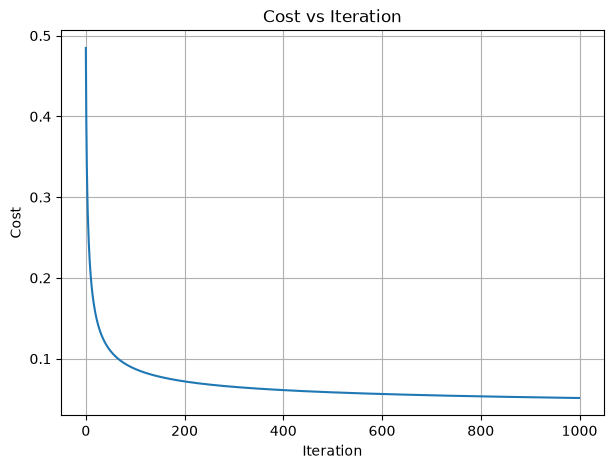

Iteration 0: cost = 0.6683
Iteration 100: cost = 0.2638
Iteration 200: cost = 0.2323
Iteration 300: cost = 0.2212
Iteration 400: cost = 0.2157
Iteration 500: cost = 0.2126
Iteration 600: cost = 0.2106
Iteration 700: cost = 0.2093
Iteration 800: cost = 0.2084
Iteration 900: cost = 0.2077


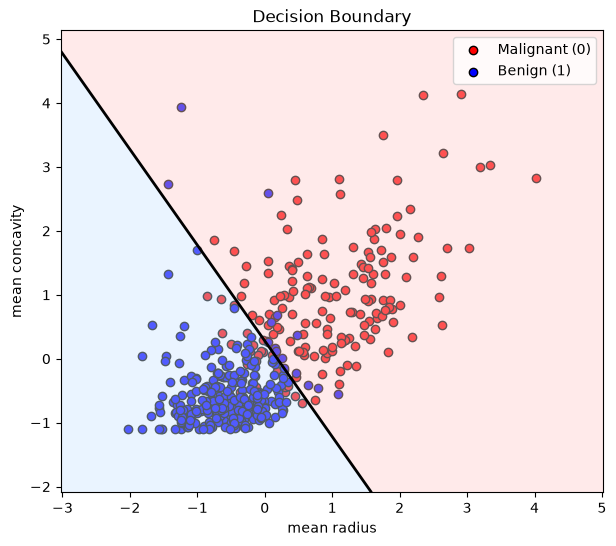

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns='target').values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
w_init = np.zeros(X_train.shape[1])
b_init = 0.0

w, b, cost_history = gradient_descent(
    X_train, y_train, w_init, b_init,
    alpha=0.1, num_iters=1000
)

plot_cost(cost_history)
feat1, feat2 = 'mean radius', 'mean concavity'

X_2d = df[[feat1, feat2]].values
X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(
    X_2d, y, test_size=0.2, random_state=42, stratify=y
)

scaler_2d = StandardScaler()
X_2d_train = scaler_2d.fit_transform(X_2d_train)

w_2d = np.zeros(2)
b_2d = 0.0
w_2d, b_2d, _ = gradient_descent(X_2d_train, y_2d_train, w_2d, b_2d, alpha=0.1, num_iters=1000)

plot_decision_boundary(X_2d_train, y_2d_train, w_2d, b_2d, feature_names=(feat1, feat2))

the module looks fit but we still need to run  evaluation test 


In [77]:
y_pred_train = predict(X_train, w, b)
y_pred_test = predict(X_test, w, b)

print("=== TRAIN ===")
train_metrics = evaluate(y_train, y_pred_train)

print("\n=== TEST ===")
test_metrics = evaluate(y_test, y_pred_test)

print(f"\nAccuracy gap (train - test): {train_metrics['accuracy'] - test_metrics['accuracy']:.4f}")

=== TRAIN ===
Confusion Matrix:
               Predicted 0   Predicted 1
Actual 0       166          4
Actual 1       2            283

Accuracy:  0.9868
Precision: 0.9861
Recall:    0.9930
F1 Score:  0.9895

=== TEST ===
Confusion Matrix:
               Predicted 0   Predicted 1
Actual 0       41           1
Actual 1       1            71

Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1 Score:  0.9861

Accuracy gap (train - test): 0.0044


now lets do a second expirement so we force overfitting 

but first we need a plotting that can show the problem 

In [78]:
def plot_decision_boundary_poly(X_raw, y, w, b, poly, scaler, feature_names=('Feature 1','Feature 2')):
    plt.figure(figsize=(7,6))
    plt.scatter(X_raw[y==0][:,0], X_raw[y==0][:,1], c='red', label='Malignant (0)', edgecolor='k')
    plt.scatter(X_raw[y==1][:,0], X_raw[y==1][:,1], c='blue', label='Benign (1)', edgecolor='k')

    x1_min, x1_max = X_raw[:,0].min()-2, X_raw[:,0].max()+2
    x2_min, x2_max = X_raw[:,1].min()-2, X_raw[:,1].max()+2
    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 300),
                            np.linspace(x2_min, x2_max, 300))

    grid_raw = np.c_[xx1.ravel(), xx2.ravel()]         
    grid_scaled = scaler.transform(grid_raw)              
    grid_poly = poly.transform(grid_scaled)                
    probs = sigmoid(grid_poly @ w + b).reshape(xx1.shape)

    plt.contour(xx1, xx2, probs, levels=[0.5], colors='black', linewidths=2)
    plt.contourf(xx1, xx2, probs, levels=[0,0.5,1], colors=['#ffcccc','#cce5ff'], alpha=0.4)

    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title('Decision Boundary (Overfit — degree 8 polynomial)')
    plt.legend()
    plt.show()

Original features: 36
After polynomial expansion: 702
Training samples: 45
Test samples: 524
Iteration 0: cost = 0.5103
Iteration 100: cost = 0.0000
Iteration 200: cost = 0.0000
Iteration 300: cost = 0.0000
Iteration 400: cost = 0.0000
Iteration 500: cost = 0.0000
Iteration 600: cost = 0.0000
Iteration 700: cost = 0.0000
Iteration 800: cost = 0.0000
Iteration 900: cost = 0.0000
Iteration 1000: cost = 0.0000
Iteration 1100: cost = 0.0000
Iteration 1200: cost = 0.0000
Iteration 1300: cost = 0.0000
Iteration 1400: cost = 0.0000
Iteration 1500: cost = 0.0000
Iteration 1600: cost = 0.0000
Iteration 1700: cost = 0.0000
Iteration 1800: cost = 0.0000
Iteration 1900: cost = 0.0000
Iteration 2000: cost = 0.0000
Iteration 2100: cost = 0.0000
Iteration 2200: cost = 0.0000
Iteration 2300: cost = 0.0000
Iteration 2400: cost = 0.0000
Iteration 2500: cost = 0.0000
Iteration 2600: cost = 0.0000
Iteration 2700: cost = 0.0000
Iteration 2800: cost = 0.0000
Iteration 2900: cost = 0.0000
Iteration 3000: cos

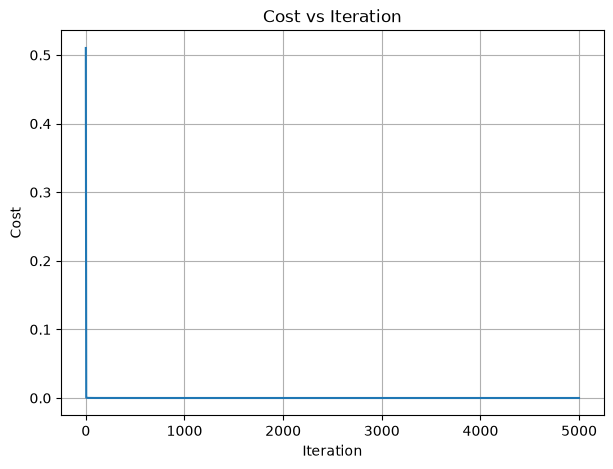

Iteration 0: cost = 8.8758
Iteration 100: cost = 0.0356
Iteration 200: cost = 0.0238
Iteration 300: cost = 0.0209
Iteration 400: cost = 0.0191
Iteration 500: cost = 0.0178
Iteration 600: cost = 0.0167
Iteration 700: cost = 0.0158
Iteration 800: cost = 0.0150
Iteration 900: cost = 0.0143
Iteration 1000: cost = 0.0136
Iteration 1100: cost = 0.0131
Iteration 1200: cost = 0.0125
Iteration 1300: cost = 0.0120
Iteration 1400: cost = 0.0116
Iteration 1500: cost = 0.0112
Iteration 1600: cost = 0.0108
Iteration 1700: cost = 0.0104
Iteration 1800: cost = 0.0101
Iteration 1900: cost = 0.0098
Iteration 2000: cost = 0.0095
Iteration 2100: cost = 0.0092
Iteration 2200: cost = 0.0089
Iteration 2300: cost = 0.0087
Iteration 2400: cost = 0.0085
Iteration 2500: cost = 0.0082
Iteration 2600: cost = 0.0080
Iteration 2700: cost = 0.0078
Iteration 2800: cost = 0.0076
Iteration 2900: cost = 0.0075
Iteration 3000: cost = 0.0073
Iteration 3100: cost = 0.0071
Iteration 3200: cost = 0.0070
Iteration 3300: cost =

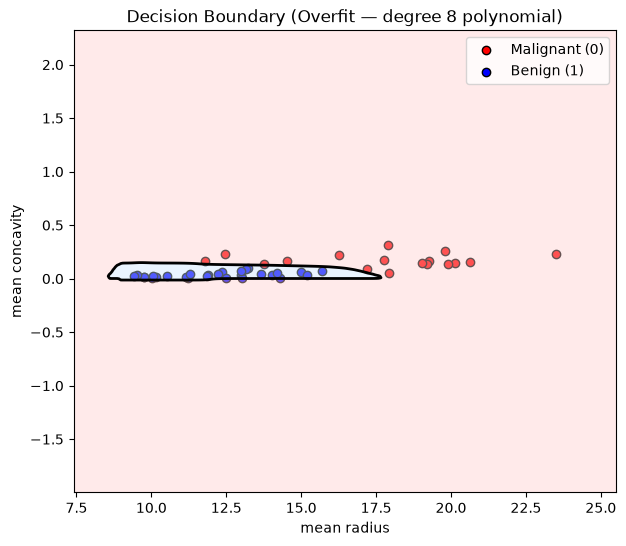

=== TRAIN (Overfit Experiment) ===
Confusion Matrix:
               Predicted 0   Predicted 1
Actual 0       17           0
Actual 1       0            28

Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000

=== TEST (Overfit Experiment) ===
Confusion Matrix:
               Predicted 0   Predicted 1
Actual 0       173          22
Actual 1       12           317

Accuracy:  0.9351
Precision: 0.9351
Recall:    0.9635
F1 Score:  0.9491

Accuracy gap (train - test): 0.0649


In [79]:


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# start from original + engineered features
X_raw = df.drop(columns='target').values
y = df['target'].values

# inflate feature count with polynomial/interaction terms
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_raw)
print("Original features:", X_raw.shape[1])
print("After polynomial expansion:", X_poly.shape[1])

# tiny training set relative to feature count
X_train_of, X_test_of, y_train_of, y_test_of = train_test_split(
    X_poly, y, train_size=0.08, random_state=42, stratify=y
)
print("Training samples:", X_train_of.shape[0])
print("Test samples:", X_test_of.shape[0])

scaler_of = StandardScaler()
X_train_of = scaler_of.fit_transform(X_train_of)
X_test_of = scaler_of.transform(X_test_of)

# train, no regularization, many iterations
w_init_of = np.zeros(X_train_of.shape[1])
b_init_of = 0.0

w_of, b_of, cost_history_of = gradient_descent(
    X_train_of, y_train_of, w_init_of, b_init_of,
    alpha=0.5, num_iters=5000
)

plot_cost(cost_history_of)
# ===== Decision boundary showing overfitting (clean run) =====

feat1, feat2 = 'mean radius', 'mean concavity'
X_2d_raw = df[[feat1, feat2]].values

X_2d_train_of, X_2d_test_of, y_2d_train_of, y_2d_test_of = train_test_split(
    X_2d_raw, y, train_size=0.08, random_state=42, stratify=y
)

# STEP 1: scale the 2 raw features (fit on 2 columns)
scaler_2d_of = StandardScaler()
X_2d_train_scaled = scaler_2d_of.fit_transform(X_2d_train_of)

# STEP 2: expand the SCALED features to polynomial terms (fit on 2 columns -> 44 columns out)
poly_2d = PolynomialFeatures(degree=8, include_bias=False)
X_2d_train_poly = poly_2d.fit_transform(X_2d_train_scaled)

w_2d_of = np.zeros(X_2d_train_poly.shape[1])
b_2d_of = 0.0

w_2d_of, b_2d_of, _ = gradient_descent(
    X_2d_train_poly, y_2d_train_of, w_2d_of, b_2d_of,
    alpha=0.3, num_iters=8000
)



plot_decision_boundary_poly(X_2d_train_of, y_2d_train_of, w_2d_of, b_2d_of,
                              poly_2d, scaler_2d_of, feature_names=(feat1, feat2))
# evaluate
y_pred_train_of = predict(X_train_of, w_of, b_of)
y_pred_test_of = predict(X_test_of, w_of, b_of)

print("=== TRAIN (Overfit Experiment) ===")
train_metrics_of = evaluate(y_train_of, y_pred_train_of)

print("\n=== TEST (Overfit Experiment) ===")
test_metrics_of = evaluate(y_test_of, y_pred_test_of)

print(f"\nAccuracy gap (train - test): {train_metrics_of['accuracy'] - test_metrics_of['accuracy']:.4f}")

## as u can notice the decision boundary is messed up its obviosly overfitting only around our data

## the solution to that problem is regularization 

1.first we need a new compute cost function 

In [80]:
def compute_cost_reg(X, y, w, b, lamb):
    m = X.shape[0]
    return compute_cost(X, y, w, b) + (lamb / (2 * m)) * np.sum(w ** 2)

1. we need a new copute gradient function 

In [81]:
def compute_gradient_reg(X, y, w, b, lamb):
    m = X.shape[0]
    dw, db = compute_gradient(X, y, w, b)
    dw = dw + (lamb / m) * w
    return dw, db

2.then gradient descent 

In [82]:
def gradient_descent_reg(X, y, w, b, alpha, num_iters, lamb):
    history = []
    for i in range(num_iters):
        dw, db = compute_gradient_reg(X, y, w, b, lamb)
        w = w - alpha * dw
        b = b - alpha * db
        history.append(compute_cost_reg(X, y, w, b, lamb))
    return w, b, history

## now lets test 

Original features: 36
After polynomial expansion: 702
Training samples: 45
Test samples: 524


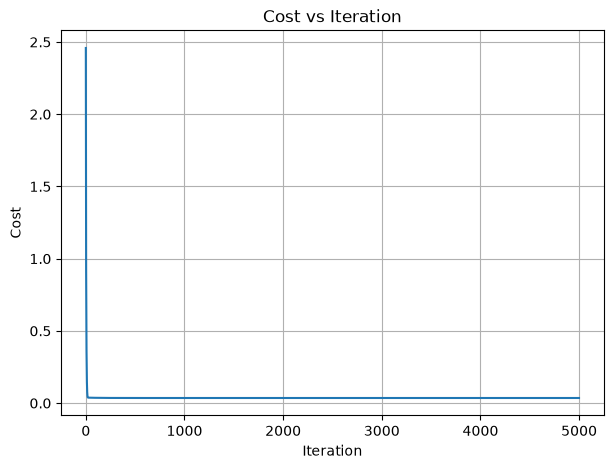

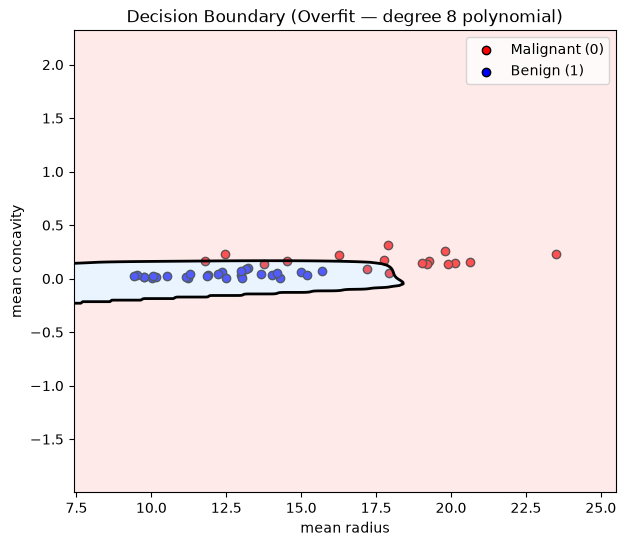

=== TRAIN (Regularized) ===
Confusion Matrix:
               Predicted 0   Predicted 1
Actual 0       17           0
Actual 1       0            28

Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000

=== TEST (Regularized) ===
Confusion Matrix:
               Predicted 0   Predicted 1
Actual 0       164          31
Actual 1       5            324

Accuracy:  0.9313
Precision: 0.9127
Recall:    0.9848
F1 Score:  0.9474

Accuracy gap (train - test): 0.0687


In [85]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# start from original + engineered features
X_raw = df.drop(columns='target').values
y = df['target'].values

# inflate feature count with polynomial/interaction terms
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_raw)
print("Original features:", X_raw.shape[1])
print("After polynomial expansion:", X_poly.shape[1])

# tiny training set relative to feature count
X_train_of, X_test_of, y_train_of, y_test_of = train_test_split(
    X_poly, y, train_size=0.08, random_state=42, stratify=y
)
print("Training samples:", X_train_of.shape[0])
print("Test samples:", X_test_of.shape[0])

scaler_of = StandardScaler()
X_train_of = scaler_of.fit_transform(X_train_of)
X_test_of = scaler_of.transform(X_test_of)

# train WITH regularization
w_init_of = np.zeros(X_train_of.shape[1])
b_init_of = 0.0

w_of, b_of, cost_history_of = gradient_descent_reg(
    X_train_of, y_train_of, w_init_of, b_init_of,
    alpha=0.5, num_iters=5000, lamb=10
)

plot_cost(cost_history_of)

# ===== Decision boundary showing regularization effect =====

feat1, feat2 = 'mean radius', 'mean concavity'
X_2d_raw = df[[feat1, feat2]].values

X_2d_train_of, X_2d_test_of, y_2d_train_of, y_2d_test_of = train_test_split(
    X_2d_raw, y, train_size=0.08, random_state=42, stratify=y
)

scaler_2d_of = StandardScaler()
X_2d_train_scaled = scaler_2d_of.fit_transform(X_2d_train_of)

poly_2d = PolynomialFeatures(degree=8, include_bias=False)
X_2d_train_poly = poly_2d.fit_transform(X_2d_train_scaled)

w_2d_of = np.zeros(X_2d_train_poly.shape[1])
b_2d_of = 0.0

w_2d_of, b_2d_of, _ = gradient_descent_reg(
    X_2d_train_poly, y_2d_train_of, w_2d_of, b_2d_of,
    alpha=0.3, num_iters=8000, lamb=10
)

plot_decision_boundary_poly(X_2d_train_of, y_2d_train_of, w_2d_of, b_2d_of,
                              poly_2d, scaler_2d_of, feature_names=(feat1, feat2))

# evaluate
y_pred_train_of = predict(X_train_of, w_of, b_of)
y_pred_test_of = predict(X_test_of, w_of, b_of)

print("=== TRAIN (Regularized) ===")
train_metrics_of = evaluate(y_train_of, y_pred_train_of)

print("\n=== TEST (Regularized) ===")
test_metrics_of = evaluate(y_test_of, y_pred_test_of)

print(f"\nAccuracy gap (train - test): {train_metrics_of['accuracy'] - test_metrics_of['accuracy']:.4f}")

## note : even after the regularization the module still overfit and it seems the number of features compared to samples is so high so we try w the original features

Iteration 0: cost = 0.4847
Iteration 100: cost = 0.0873
Iteration 200: cost = 0.0719
Iteration 300: cost = 0.0651
Iteration 400: cost = 0.0611
Iteration 500: cost = 0.0583
Iteration 600: cost = 0.0563
Iteration 700: cost = 0.0547
Iteration 800: cost = 0.0533
Iteration 900: cost = 0.0523


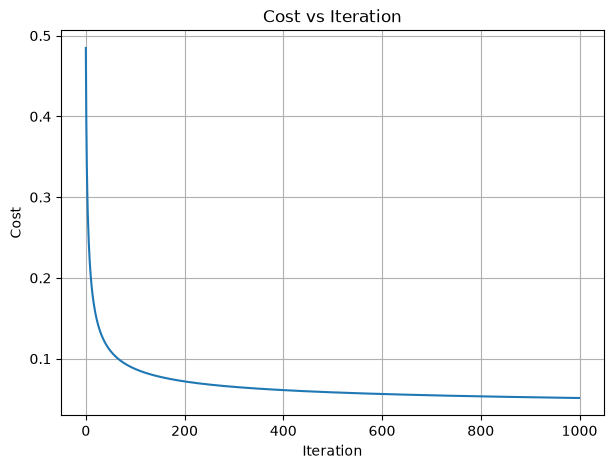

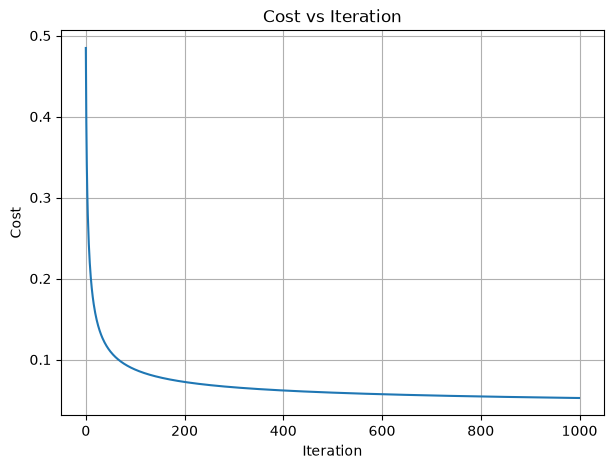

=== TRAIN (Regularized) ===
Confusion Matrix:
               Predicted 0   Predicted 1
Actual 0       166          4
Actual 1       2            283

Accuracy:  0.9868
Precision: 0.9861
Recall:    0.9930
F1 Score:  0.9895

=== TEST (Regularized) ===
Confusion Matrix:
               Predicted 0   Predicted 1
Actual 0       41           1
Actual 1       1            71

Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1 Score:  0.9861

Accuracy gap (train - test): 0.0044


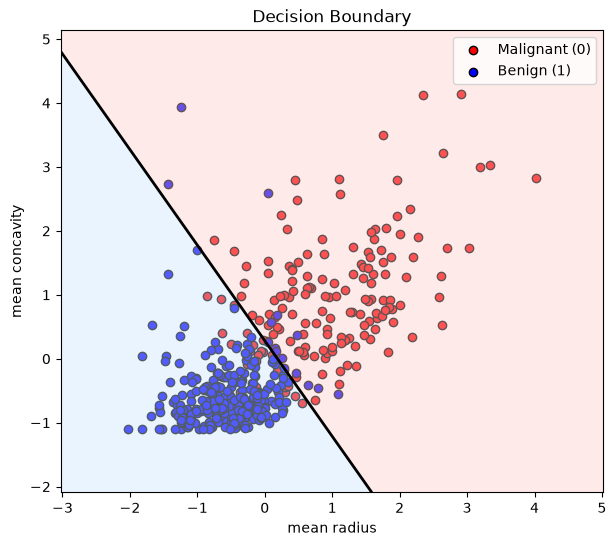

In [86]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Use the full feature set, not a tiny training split
X = df.drop(columns='target').values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Baseline (no regularization)
w = np.zeros(X_train.shape[1])
b = 0.0
w, b, cost_history = gradient_descent(
    X_train, y_train, w, b, alpha=0.1, num_iters=1000
)

plot_cost(cost_history)

# Regularized version
w_reg = np.zeros(X_train.shape[1])
b_reg = 0.0
w_reg, b_reg, cost_history_reg = gradient_descent_reg(
    X_train, y_train, w_reg, b_reg, alpha=0.1, num_iters=1000, lamb=0.1
)

plot_cost(cost_history_reg)

# Evaluate
y_pred_train = predict(X_train, w_reg, b_reg)
y_pred_test = predict(X_test, w_reg, b_reg)

print("=== TRAIN (Regularized) ===")
train_metrics = evaluate(y_train, y_pred_train)

print("\n=== TEST (Regularized) ===")
test_metrics = evaluate(y_test, y_pred_test)

print(f"\nAccuracy gap (train - test): {train_metrics['accuracy'] - test_metrics['accuracy']:.4f}")

# ===== Decision boundary (regularized, 2 features) =====

feat1, feat2 = 'mean radius', 'mean concavity'
X_2d = df[[feat1, feat2]].values

X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(
    X_2d, y, test_size=0.2, random_state=42, stratify=y
)

scaler_2d = StandardScaler()
X_2d_train = scaler_2d.fit_transform(X_2d_train)

w_2d = np.zeros(2)
b_2d = 0.0

w_2d, b_2d, _ = gradient_descent_reg(
    X_2d_train, y_2d_train, w_2d, b_2d, alpha=0.1, num_iters=1000, lamb=0.1
)

plot_decision_boundary(X_2d_train, y_2d_train, w_2d, b_2d, feature_names=(feat1, feat2))

## experiment finished 